In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [3]:
data_df = pd.read_csv('../data/train.csv', index_col='PassengerId')

In [4]:
# Fill the data with sum miss value > 0
missing_data = data_df.isnull().sum()
print(missing_data[missing_data > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [6]:
target = 'Survived'

In [7]:
x = data_df.drop(columns=[target], axis = 1)
y = data_df[target]

In [8]:
# Stratify ( phân chia để k bị lệch data giữa train và test)
X_train, X_test, Y_train, Y_test = train_test_split(x,y, train_size = 0.8, random_state=1)

In [9]:
# học prefix hiếm từ train
train_ticket_prefix = X_train['Ticket'].str.replace(r'[0-9./]', '', regex=True).str.strip()
train_ticket_prefix = train_ticket_prefix.replace('', 'NONE')

prefix_counts = train_ticket_prefix.value_counts()
rare_prefixes = prefix_counts[prefix_counts < 10].index.tolist()

# áp dụng cho train và test
def make_ticket_prefix(ticket, rare_prefixes):
    prefix = pd.Series([ticket]).str.replace(r'[0-9./]', '', regex=True).str.strip().iloc[0]
    prefix = 'NONE' if prefix == '' else prefix
    return 'RARE' if prefix in rare_prefixes else prefix

X_train['TicketPrefix'] = X_train['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))
X_test['TicketPrefix'] = X_test['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))

In [10]:
X_train.TicketPrefix.value_counts()

TicketPrefix
NONE       533
RARE        51
PC          50
CA          31
A           21
SOTONOQ     14
STONO       12
Name: count, dtype: int64

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin
class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        group_cols=['Sex', 'Pclass'],
        target_col='Age'
    ):
        self.group_cols = group_cols
        self.target_col = target_col
        self.group_median_ = None
        self.global_median_ = None

    def fit(self, X, y=None):
        X = X.copy()

        # median theo nhóm
        self.group_median_ = (
            X.groupby(self.group_cols)[self.target_col]
            .median()
        )

        # median toàn cục
        self.global_median_ = X[self.target_col].median()

        return self

    def _fill_row(self, row):
        if pd.notna(row[self.target_col]):
            return row[self.target_col]

        key = tuple(row[col] for col in self.group_cols)

        if key in self.group_median_.index:
            val = self.group_median_.loc[key]
            if pd.notna(val):
                return val

        return self.global_median_

    def transform(self, X):
        X = X.copy()

        X[self.target_col] = X.apply(self._fill_row, axis=1)

        return X

In [12]:
# Sex
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

# Title
X_train['Title'] = X_train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
X_test['Title'] = X_test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

for data in [X_train, X_test]:
    data['Title'] = data['Title'].replace(title_mapping)
    data['Title'] = data['Title'].replace(rare_titles, 'Rare')

In [13]:
X_train.Title.value_counts()

Title
Mr        415
Miss      145
Mrs       102
Master     32
Rare       18
Name: count, dtype: int64

In [14]:
X_train['Deck'] = X_train['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])
X_test['Deck'] = X_test['Cabin'].apply(lambda x: 'U' if pd.isna(x) else str(x)[0])

In [15]:
X_train.Deck.value_counts()

Deck
U    547
C     51
B     35
D     26
E     24
A     13
F     12
G      3
T      1
Name: count, dtype: int64

In [16]:
cols_to_drop = ['Cabin', 'Ticket', 'Name']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [17]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
cate_nor_feature = ['TicketPrefix','Sex', 'Embarked', 'Title', 'Deck']
cate_or_feature = ['Pclass']

In [18]:
age_imputer = AgeImputer()

X_train = age_imputer.fit_transform(X_train)
X_test = age_imputer.transform(X_test)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

categorical_nor_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
categorical_or_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]]))
])
# Gộp preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat_nor', categorical_nor_transformer, cate_nor_feature),
    ('cat_ord',categorical_or_transformer, cate_or_feature)
]) 

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Khai báo các model, tinh chỉnh thông số ở đây
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = {}
pipelines = {}

# Train từng model thông qua pipeline
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, Y_train)
    acc = pipeline.score(X_test, Y_test)
    
    results[name] = acc
    pipelines[name] = pipeline
    
    print(f"{name}: Accuracy = {acc:.4f}")

# Chọn model tốt nhất
best_name = max(results, key=results.get)
best_pipeline = pipelines[best_name]

print(f"\nChọn model: {best_name}")

Logistic Regression: Accuracy = 0.8045
Random Forest: Accuracy = 0.7709
SVM: Accuracy = 0.8045

Chọn model: Logistic Regression


Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       106
           1       0.77      0.74      0.76        73

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[90 16]
 [19 54]]


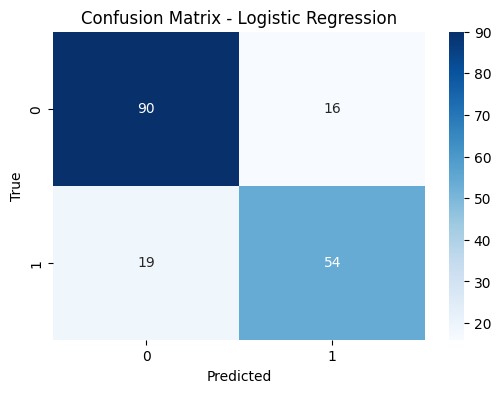

In [20]:
# ============================================
# Bước 5 - Đánh giá: classification_report, confusion_matrix
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dự đoán bằng pipeline tốt nhất
y_pred = best_pipeline.predict(X_test)

print(f"Best model: {best_name}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(Y_test, y_pred)
print(cm)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

In [21]:
# ============================================
# Bước 6 - Lưu mô hình (Pipeline)
# ============================================
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Lưu toàn bộ pipeline
joblib.dump(best_pipeline, '../models/titanic_model.joblib')
print("Đã lưu pipeline vào thư mục models/")

Đã lưu pipeline vào thư mục models/
